In [1]:
import arviz as az
import lama_aesthetics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
from scipy.constants import golden

lama_aesthetics.get_style("main")
ONE_COL_WIDTH_INCH = 3
TWO_COL_WIDTH_INCH = 7.25
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden

In [2]:


model_names_map = {"0": "Claude 4.5", "1": "GPT-4o"}

model_names_map_2 = {"Claude-4.5": "Claude 4.5", "gpt-4o": "GPT-4o"}

model_mapping = {"claude-sonnet-4.5": "Claude 4.5", "gpt-4o": "GPT-4o"}
# Rename and combine environments
env_mapping = {
    "afm": "AFM",
    "catalyst": "Catalyst",
    "md_melting": "MD",
    "md_quenching": "MD",
    "md_surface_energy": "MD",
    "ml": "ML",
    "resistor": "Resistor",
    "retrosynthesis": "Retrosynthesis",
    "spectra": "Spectra",
}

environment_name_maps_2 = {
    "spectra": "Spectra",
    "ml": "ML",
    "retrosynthesis": "Retrosynthesis",
    "resistor": "Resistor",
    "afm": "AFM",
    "catalyst": "Catalyst",
    "md": "MD",
}

environment_name_maps = {
    "7": "Spectra",
    "3": "ML",
    "5": "Retrosynthesis",
    "4": "Resistor",
    "0": "AFM",
    "1": "Catalyst",
    "2": "MD",
}

# fd00ff
model_names_color_map = {"Claude-4.5": "#8900ff", "gpt-4o": "#ff0677"}

environment_color_map = {
    "spectra": "#711c91",
    "ml": "#ea00d9",
    "retrosynthesis": "#0abdc6",
    "resistor": "#133e7c",
    "afm": "#091833",
    "catalyst": "#467fa1",
    "md": "#54295c",
}


In [3]:

qa = pd.read_csv(
    "/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/qa_scores.csv"
)

agent_data = pd.read_csv(
    "/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/overall_trace_v2.csv"
)

def fit_irt_model(qa_df):
    """
    qa_df needs columns: model_id, env_id, item_id, correct (0/1)
    """
    # Create categorical codes for proper integer indexing
    qa_df = qa_df.copy()

    # Create integer indices for models, envs, items
    qa_df["model_idx"] = pd.Categorical(qa_df["model_id"]).codes
    qa_df["env_idx"] = pd.Categorical(qa_df["env_id"]).codes
    qa_df["item_idx"] = pd.Categorical(qa_df["item_id"]).codes

    # Create theta index for each (model, env) pair
    qa_df["theta_idx"] = qa_df.groupby(["model_idx", "env_idx"]).ngroup()

    N_theta = qa_df["theta_idx"].nunique()
    N_items = qa_df["item_idx"].nunique()
    N_models = qa_df["model_idx"].nunique()
    N_envs = qa_df["env_idx"].nunique()

    print(
        f"N_models: {N_models}, N_envs: {N_envs}, N_theta: {N_theta}, N_items: {N_items}"
    )

    # Get mappings - these MUST be integer arrays
    theta_to_model = qa_df.groupby("theta_idx")["model_idx"].first().values.astype(int)
    theta_to_env = qa_df.groupby("theta_idx")["env_idx"].first().values.astype(int)

    print(f"theta_to_model: {theta_to_model}")
    print(f"theta_to_env: {theta_to_env}")

    with pm.Model() as model:
        # Only add effects if there's variation
        if N_models > 1:
            mu_raw = pm.Normal("mu_raw", 0, 1, shape=N_models - 1)
            mu = pm.Deterministic(
                "mu", pm.math.concatenate([mu_raw, [-pm.math.sum(mu_raw)]])
            )
        else:
            mu = pm.Deterministic("mu", pm.math.constant(np.array([0.0])))

        if N_envs > 1:
            nu_raw = pm.Normal("nu_raw", 0, 1, shape=N_envs - 1)
            nu = pm.Deterministic(
                "nu", pm.math.concatenate([nu_raw, [-pm.math.sum(nu_raw)]])
            )
        else:
            nu = pm.Deterministic("nu", pm.math.constant(np.array([0.0])))

        # Theta
        sigma_theta = pm.HalfNormal("sigma_theta", 0.5)
        theta_mean = mu[theta_to_model] + nu[theta_to_env]
        theta = pm.Normal("theta", mu=theta_mean, sigma=sigma_theta, shape=N_theta)

        # Item parameters
        log_a = pm.Normal("log_a", 0, 0.5, shape=N_items)
        a = pm.Deterministic("a", pm.math.exp(log_a))
        b = pm.Normal("b", 0, 2, shape=N_items)

        # Likelihood - ensure these are integer arrays too
        item_indices = qa_df["item_idx"].values.astype(int)
        theta_indices = qa_df["theta_idx"].values.astype(int)

        eta = a[item_indices] * theta[theta_indices] - b[item_indices]
        pm.Bernoulli("y", logit_p=eta, observed=qa_df["correct"].values)

        trace = pm.sample(2000, tune=1000, chains=4, target_accept=0.9)

    return trace, qa_df


def get_theta_estimates(trace, qa_df, model_names, env_names):
    """Pull out theta posteriors as a nice dataframe."""
    summary = az.summary(trace, var_names=["theta"], hdi_prob=0.9)

    theta_to_model = qa_df.groupby("theta_idx")["model_id"].first()
    theta_to_env = qa_df.groupby("theta_idx")["env_id"].first()

    results = []
    for idx in range(len(summary)):
        results.append(
            {
                "model": model_names[theta_to_model[idx]],
                "environment": env_names[theta_to_env[idx]],
                "theta_mean": summary.iloc[idx]["mean"],
                "theta_sd": summary.iloc[idx]["sd"],
            }
        )
    return pd.DataFrame(results)


def filter_extreme_groups(df, min_rate=0.05, max_rate=1):
    grouped = df.groupby(["environment", "scaffold", "level"])

    def is_valid_group(group):
        rate = group["success"].mean()
        return min_rate <= rate <= max_rate

    return grouped.filter(is_valid_group)


def fit_agent_model_no_task_effects(agent_df, theta_df):
    """
    Model without task random effects (tasks are too sparse)
    """
    agent_df = agent_df.copy()

    # Merge in theta estimates
    agent_df = agent_df.merge(
        theta_df[["model", "environment", "theta_mean"]],
        on=["model", "environment"],
        how="left",
    )

    # Check for missing theta values after merge
    missing_theta = agent_df["theta_mean"].isna().sum()
    if missing_theta > 0:
        print(f"Warning: {missing_theta} rows have missing theta_mean after merge")
        print("Unique (model, env) pairs with missing theta:")
        missing_pairs = agent_df[agent_df["theta_mean"].isna()][
            ["model", "environment"]
        ].drop_duplicates()
        print(missing_pairs)
        # Drop rows with missing theta
        agent_df = agent_df.dropna(subset=["theta_mean"])
        print(f"Dropped {missing_theta} rows, remaining: {len(agent_df)}")

    # Create indices
    agent_df["env_idx"] = pd.Categorical(agent_df["environment"]).codes
    agent_df["scaffold_idx"] = pd.Categorical(agent_df["scaffold"]).codes
    agent_df["level"] = agent_df["level"].str.extract(r"(\d+)").astype(int)
    agent_df["level_idx"] = agent_df["level"] - 1
    agent_df["verbosity_idx"] = pd.Categorical(agent_df["verbosity"]).codes

    N_envs = agent_df["env_idx"].nunique()
    N_scaffolds = agent_df["scaffold_idx"].nunique()
    N_levels = agent_df["level_idx"].nunique()
    N_verbosities = agent_df["verbosity_idx"].nunique()

    print(
        f"Model dimensions: N_envs={N_envs}, N_scaffolds={N_scaffolds}, "
        f"N_levels={N_levels}, N_verbosities={N_verbosities}"
    )

    # Success rate
    success_rate = agent_df["success"].mean()
    init_intercept = np.log(success_rate / (1 - success_rate))
    print(f"Success rate: {success_rate:.3f}, init intercept: {init_intercept:.3f}")

    # Standardize reasoning if present AND has valid non-empty values
    has_reasoning = (
        "reasoning_score" in agent_df.columns
        and agent_df["reasoning_score"].notna().any()
        and pd.to_numeric(agent_df["reasoning_score"], errors="coerce").std() > 0
    )
    if has_reasoning:
        agent_df["reasoning_score"] = pd.to_numeric(
            agent_df["reasoning_score"], errors="coerce"
        )
        agent_df["reasoning_z"] = (
            agent_df["reasoning_score"] - agent_df["reasoning_score"].mean()
        ) / agent_df["reasoning_score"].std()
        print(
            f"Reasoning score: mean={agent_df['reasoning_score'].mean():.3f}, std={agent_df['reasoning_score'].std():.3f}"
        )
    else:
        print("Note: reasoning_score not available or empty - modeling without it")

    # Standardize theta
    theta_mean = agent_df["theta_mean"].mean()
    theta_std = agent_df["theta_mean"].std()
    agent_df["theta_z"] = (agent_df["theta_mean"] - theta_mean) / theta_std
    print(f"Theta: mean={theta_mean:.3f}, std={theta_std:.3f}")

    with pm.Model() as model:
        # Intercept
        beta0 = pm.Normal("beta0", init_intercept, 10)

        # Knowledge loading per environment
        lam = pm.Normal("lambda", 0, 1, shape=N_envs)

        # Scaffold effect
        gamma = pm.Normal("gamma", 0, 1, shape=N_scaffolds)

        # Level effect (harder levels have more negative effects)
        delta_inc = pm.HalfNormal("delta_inc", 0.5, shape=N_levels - 1)
        delta = pm.Deterministic(
            "delta", pm.math.concatenate([[0], -pm.math.cumsum(delta_inc)])
        )

        # Verbosity
        xi = pm.Normal("xi", 0, 0.5, shape=N_verbosities)

        # Build linear predictor
        env_idx = agent_df["env_idx"].values.astype(int)
        scaffold_idx = agent_df["scaffold_idx"].values.astype(int)
        level_idx = agent_df["level_idx"].values.astype(int)
        verbosity_idx = agent_df["verbosity_idx"].values.astype(int)
        theta_vals = agent_df["theta_z"].values.astype(float)

        linpred = (
            beta0
            + lam[env_idx] * theta_vals
            + gamma[scaffold_idx]
            + delta[level_idx]
            + xi[verbosity_idx]
        )

        # Optional: scaffold × reasoning interaction
        if has_reasoning:
            psi = pm.Normal("psi", 0, 0.3, shape=N_scaffolds)
            linpred = linpred + psi[scaffold_idx] * agent_df["reasoning_z"].values

        # Likelihood - use linpred directly with logit_p
        pm.Bernoulli("y", logit_p=linpred, observed=agent_df["success"].values)

        print("\nTesting initial point...")
        try:
            test_point = model.initial_point()
            # Use point_logps() for PyMC v5
            logp_dict = model.point_logps(test_point)
            total_logp = sum(logp_dict.values())
            print(f"Initial log probability: {total_logp:.2f}")
            if np.isfinite(total_logp):
                print("✓ Initial point is valid!")
                print(f"Component logps: {logp_dict}")
            else:
                print("⚠ Warning: Initial point has non-finite logp")
                print(f"Component logps: {logp_dict}")
        except Exception as e:
            print(f"Error during initial point test: {e}")

        trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95)

    return trace, agent_df


def variance_decomposition(trace, agent_df, include_task=False):
    """
    Compute how much variance each component explains.
    """
    # Get posterior means
    lam = trace.posterior["lambda"].mean(dim=["chain", "draw"]).values
    gamma = trace.posterior["gamma"].mean(dim=["chain", "draw"]).values
    delta = trace.posterior["delta"].mean(dim=["chain", "draw"]).values
    xi = trace.posterior["xi"].mean(dim=["chain", "draw"]).values

    # Compute component values for each observation
    knowledge = lam[agent_df["env_idx"]] * agent_df["theta_z"]
    scaffold = gamma[agent_df["scaffold_idx"]]
    level = delta[agent_df["level_idx"]]
    verbosity = xi[agent_df["verbosity_idx"]]

    vars_dict = {
        "knowledge": np.var(knowledge),
        "scaffold": np.var(scaffold),
        "level": np.var(level),
        "verbosity": np.var(verbosity),
    }

    # Include task random effects if present
    if include_task and "eta" in trace.posterior:
        eta = trace.posterior["eta"].mean(dim=["chain", "draw"]).values
        task = eta[agent_df["task_idx"]]
        vars_dict["task"] = np.var(task)

    total = sum(vars_dict.values())

    return {k: 100 * v / total for k, v in vars_dict.items()}


def fit_agent_model_with_task_effects(agent_df, theta_df):
    """
    Full model WITH task-specific random intercepts (η_t).
    Use when you have sufficient trials per task (>30 recommended).
    """
    agent_df = agent_df.copy()

    # Merge in theta estimates
    agent_df = agent_df.merge(
        theta_df[["model", "environment", "theta_mean"]],
        on=["model", "environment"],
        how="left",
    )

    # Check for missing theta values after merge
    missing_theta = agent_df["theta_mean"].isna().sum()
    if missing_theta > 0:
        print(f"Warning: {missing_theta} rows have missing theta_mean after merge")
        agent_df = agent_df.dropna(subset=["theta_mean"])
        print(f"Dropped {missing_theta} rows, remaining: {len(agent_df)}")

    # Create indices
    agent_df["env_idx"] = pd.Categorical(agent_df["environment"]).codes
    agent_df["task_idx"] = pd.Categorical(agent_df["task"]).codes
    agent_df["scaffold_idx"] = pd.Categorical(agent_df["scaffold"]).codes
    agent_df["level"] = agent_df["level"].str.extract(r"(\d+)").astype(int)
    agent_df["level_idx"] = agent_df["level"] - 1
    agent_df["verbosity_idx"] = pd.Categorical(agent_df["verbosity"]).codes

    N_envs = agent_df["env_idx"].nunique()
    N_tasks = agent_df["task_idx"].nunique()
    N_scaffolds = agent_df["scaffold_idx"].nunique()
    N_levels = agent_df["level_idx"].nunique()
    N_verbosities = agent_df["verbosity_idx"].nunique()

    print(
        f"Model dimensions: N_envs={N_envs}, N_tasks={N_tasks}, N_scaffolds={N_scaffolds}, "
        f"N_levels={N_levels}, N_verbosities={N_verbosities}"
    )

    # Success rate
    success_rate = agent_df["success"].mean()
    init_intercept = np.log(success_rate / (1 - success_rate))
    print(f"Success rate: {success_rate:.3f}, init intercept: {init_intercept:.3f}")

    # Standardize reasoning if present
    has_reasoning = (
        "reasoning_score" in agent_df.columns
        and agent_df["reasoning_score"].notna().any()
        and pd.to_numeric(agent_df["reasoning_score"], errors="coerce").std() > 0
    )
    if has_reasoning:
        agent_df["reasoning_score"] = pd.to_numeric(
            agent_df["reasoning_score"], errors="coerce"
        )
        agent_df["reasoning_z"] = (
            agent_df["reasoning_score"] - agent_df["reasoning_score"].mean()
        ) / agent_df["reasoning_score"].std()
        print(
            f"Reasoning score: mean={agent_df['reasoning_score'].mean():.3f}, std={agent_df['reasoning_score'].std():.3f}"
        )
    else:
        print("Note: reasoning_score not available - modeling without it")

    # Standardize theta
    theta_mean = agent_df["theta_mean"].mean()
    theta_std = agent_df["theta_mean"].std()
    agent_df["theta_z"] = (agent_df["theta_mean"] - theta_mean) / theta_std
    print(f"Theta: mean={theta_mean:.3f}, std={theta_std:.3f}")

    with pm.Model() as model:
        # Intercept
        beta0 = pm.Normal("beta0", init_intercept, 10)

        # Knowledge loading per environment (expect positive, ~1)
        lam = pm.Normal("lambda", 1, 0.5, shape=N_envs)

        # Scaffold effect
        gamma = pm.Normal("gamma", 0, 1, shape=N_scaffolds)

        # Level effect (enforce ordering via cumulative negative increments)
        delta_inc = pm.HalfNormal("delta_inc", 0.5, shape=N_levels - 1)
        delta = pm.Deterministic(
            "delta", pm.math.concatenate([[0], -pm.math.cumsum(delta_inc)])
        )

        # Task random effects
        sigma_task = pm.HalfNormal("sigma_task", 1)
        eta = pm.Normal("eta", 0, sigma_task, shape=N_tasks)

        # Verbosity
        xi = pm.Normal("xi", 0, 0.5, shape=N_verbosities)

        # Build linear predictor
        env_idx = agent_df["env_idx"].values.astype(int)
        task_idx = agent_df["task_idx"].values.astype(int)
        scaffold_idx = agent_df["scaffold_idx"].values.astype(int)
        level_idx = agent_df["level_idx"].values.astype(int)
        verbosity_idx = agent_df["verbosity_idx"].values.astype(int)
        theta_vals = agent_df["theta_z"].values.astype(float)

        linpred = (
            beta0
            + lam[env_idx] * theta_vals
            + gamma[scaffold_idx]
            + delta[level_idx]
            + eta[task_idx]
            + xi[verbosity_idx]
        )

        # Optional: scaffold × reasoning interaction
        if has_reasoning:
            psi = pm.Normal("psi", 0, 0.5, shape=N_scaffolds)
            linpred = linpred + psi[scaffold_idx] * agent_df["reasoning_z"].values

        pm.Bernoulli("y", logit_p=linpred, observed=agent_df["success"].values)

        print("\nTesting initial point...")
        try:
            test_point = model.initial_point()
            logp_dict = model.point_logps(test_point)
            total_logp = sum(logp_dict.values())
            print(f"Initial log probability: {total_logp:.2f}")
            if np.isfinite(total_logp):
                print("✓ Initial point is valid!")
            else:
                print("⚠ Warning: Initial point has non-finite logp")
                print(f"Component logps: {logp_dict}")
        except Exception as e:
            print(f"Error during initial point test: {e}")

        trace = pm.sample(2000, tune=1000, chains=4, target_accept=0.9)

    return trace, agent_df


In [11]:

# =============================================================================
# PLOTTING FUNCTIONS
# =============================================================================


def plot_capability_heatmap(theta_df, output_path="capability_heatmap.png"):
    """
    Figure 1: Capability Heatmap
    Heatmap of θ_{m,d} estimates. Rows = models, columns = environments.
    """
    # Pivot to matrix form
    pivot = theta_df.pivot(index="model", columns="environment", values="theta_mean")

    fig, ax = plt.subplots(
        figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH)
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        center=0,
        ax=ax,
        cbar_kws={"label": "Capability (θ)"},
    )

    ax.set_title(
        "Model Capability by Domain\n(θ estimates from IRT)",
        fontsize=6,
        fontweight="bold",
    )
    ax.set_xlabel("Environment")
    ax.set_ylabel("Model")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_lambda_forest(trace, env_names, output_path="lambda_forest.png"):
    """
    Figure 2: Knowledge Loading by Environment
    Forest plot of λ_d estimates with 90% credible intervals.
    """
    lam_summary = az.summary(trace, var_names=["lambda"], hdi_prob=0.9)

    # Create environment name mapping
    env_list = list(env_names) if isinstance(env_names, dict) else env_names

    fig, ax = plt.subplots(
        figsize=(TWO_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH)
    )

    # Sort by mean
    order = lam_summary["mean"].argsort()
    y_pos = np.arange(len(lam_summary))

    means = lam_summary["mean"].iloc[order].values
    lows = lam_summary["hdi_5%"].iloc[order].values
    highs = lam_summary["hdi_95%"].iloc[order].values

    ax.errorbar(
        means,
        y_pos,
        xerr=[means - lows, highs - means],
        fmt="o",
        capsize=4,
        color="steelblue",
        markersize=8,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels([env_list[i] for i in order])
    ax.axvline(1, color="gray", linestyle="--", alpha=0.7, label="λ=1 (proportional)")
    ax.axvline(0, color="gray", linestyle=":", alpha=0.5, label="λ=0 (no effect)")

    # Add interpretation zones
    xlim = ax.get_xlim()
    ax.axvspan(1.2, xlim[1], alpha=0.1, color="#0051ff", label="Knowledge-limited")
    ax.axvspan(xlim[0], 0.5, alpha=0.1, color="#ff0677", label="Execution-limited")

    ax.set_xlabel("Knowledge Loading (λ)", fontsize=8)
    ax.set_title(
        "How Much Does Domain Knowledge Matter?", fontsize=8, fontweight="bold"
    )
    ax.legend(loc="lower right", fontsize=6)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_variance_decomposition(var_dict, output_path="variance_decomposition.png"):
    """
    Figure 3: Variance Decomposition
    Bar chart showing percentage of variance from each source.
    """
    fig, ax = plt.subplots(
        figsize=(ONE_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH)
    )

    # Sort by variance explained
    sorted_items = sorted(var_dict.items(), key=lambda x: x[1], reverse=True)
    labels = [item[0].capitalize() for item in sorted_items]
    values = [item[1] for item in sorted_items]

    # colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

    # e84ab5	(232,74,181)
    # a052c3	(160,82,195)
    # 5f59d0	(95,89,208)
    # 668fb6	(102,143,182)
    # 6bb5a4
    colors = ["#5f59d0", "#e84ab5", "#a052c3", "#668fb6", "#6bb5a4"]

    bars = ax.barh(labels, values, color=colors,)# edgecolor="black", linewidth=0.5)

    # Add percentage labels
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            fontsize=7,
        )

    ax.set_xlabel("Variance Explained (%)", fontsize=6)
    ax.set_title("Variance Decomposition", fontsize=6, fontweight="bold")
    ax.set_xlim(0, max(values) * 1.15)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_capability_profiles(theta_df, output_path="capability_profiles.png"):
    """
    Figure 4: Model Capability Profiles
    Line plot with environments on x-axis, θ on y-axis, one line per model.
    """
    fig, ax = plt.subplots(
        figsize=(TWO_COL_WIDTH_INCH, 1.5*ONE_COL_GOLDEN_RATIO_HEIGHT_INCH*1.5)
    )

    models = theta_df["model"].unique()
    # colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    # model_names_map_2 = {"Claude-4.5": "#8900ff", "gpt-4o": "#ff0677"}
    colors = ["#8900ff", "#ff0677"]

    for model, color in zip(models, colors):
        model_data = theta_df[theta_df["model"] == model].sort_values("environment")
        ax.plot(
            model_data["environment"],
            model_data["theta_mean"],
            marker="o",
            label=model,
            color=color,
            linewidth=2,
            markersize=8,
        )

        # Add error bars if theta_sd is available
        if "theta_sd" in model_data.columns:
            ax.fill_between(
                model_data["environment"],
                model_data["theta_mean"] - model_data["theta_sd"],
                model_data["theta_mean"] + model_data["theta_sd"],
                alpha=0.2,
                color=color,
            )

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel("Capability (θ)", fontsize=8)
    ax.set_title(
        "Model Capability Profiles Across Domains", fontsize=8, fontweight="bold"
    )
    ax.legend(loc="best")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_scaffold_effects(trace, scaffold_names, output_path="scaffold_effects.png"):
    """
    Additional: Scaffold effect estimates with credible intervals.
    """
    gamma_summary = az.summary(trace, var_names=["gamma"], hdi_prob=0.9)

    fig, ax = plt.subplots(
        figsize=(ONE_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH)
    )

    scaffold_list = (
        list(scaffold_names) if isinstance(scaffold_names, dict) else scaffold_names
    )

    y_pos = np.arange(len(gamma_summary))
    means = gamma_summary["mean"].values
    lows = gamma_summary["hdi_5%"].values
    highs = gamma_summary["hdi_95%"].values

    ax.errorbar(
        means,
        y_pos,
        xerr=[means - lows, highs - means],
        fmt="o",
        capsize=4,
        color="#711c91",
        markersize=8,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(scaffold_list, fontsize=7)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_xlabel("Effect on Log-Odds\n of Success", fontsize=6)
    ax.set_title("Scaffold Effects (γ)", fontsize=8, fontweight="bold")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_level_effects(trace, output_path="level_effects.png"):
    """
    Additional: Level difficulty effects.
    """
    delta_summary = az.summary(trace, var_names=["delta"], hdi_prob=0.9)

    fig, ax = plt.subplots(
        figsize=(ONE_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH)
    )

    levels = [f"Level {i+1}" for i in range(len(delta_summary))]
    y_pos = np.arange(len(delta_summary))
    means = delta_summary["mean"].values
    lows = delta_summary["hdi_5%"].values
    highs = delta_summary["hdi_95%"].values

    ax.errorbar(
        means,
        y_pos,
        xerr=[means - lows, highs - means],
        fmt="o",
        capsize=4,
        color="#6300ff",
        markersize=8,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(levels)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_xlabel("Effect on Log-Odds\n of Success", fontsize=6)
    ax.set_title("Level Difficulty (δ)", fontsize=8, fontweight="bold")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def generate_all_plots(
    irt_trace, agent_trace, theta_df, agent_df, var_decomp, output_dir="."
):
    """
    Generate all figures for the paper.
    """
    import os

    os.makedirs(output_dir, exist_ok=True)

    # Get unique environment and scaffold names from agent_df
    env_names = sorted(agent_df["environment"].unique())
    scaffold_names = sorted(agent_df["scaffold"].unique())

    print("\n" + "=" * 60)
    print("Generating plots...")
    print("=" * 60)

    # Figure 1: Capability Heatmap
    plot_capability_heatmap(theta_df, f"{output_dir}/fig1_capability_heatmap.png")

    # Figure 2: Knowledge Loading Forest
    plot_lambda_forest(agent_trace, env_names, f"{output_dir}/fig2_lambda_forest.png")

    # Figure 3: Variance Decomposition
    plot_variance_decomposition(
        var_decomp, f"{output_dir}/fig3_variance_decomposition.png"
    )

    # Figure 4: Capability Profiles
    plot_capability_profiles(theta_df, f"{output_dir}/fig4_capability_profiles.png")

    # Additional plots
    plot_scaffold_effects(
        agent_trace, scaffold_names, f"{output_dir}/fig5_scaffold_effects.png"
    )
    plot_level_effects(agent_trace, f"{output_dir}/fig6_level_effects.png")

    print("\n" + "=" * 60)
    print(f"All plots saved to {output_dir}/")
    print("=" * 60)







In [8]:

# if __name__ == "__main__":
#     import argparse

#     parser = argparse.ArgumentParser(
#         description="Latent Factor Model for Agent Benchmarks"
#     )
#     parser.add_argument(
#         "--with-task-effects", action="store_true", help="Include task random effects"
#     )
#     parser.add_argument(
#         "--plots-only",
#         action="store_true",
#         help="Skip fitting, just generate plots from saved traces",
#     )
#     parser.add_argument(
#         "--output-dir", default="./plots", help="Output directory for plots"
#     )
#     args = parser.parse_args()

# ==========================================================================
# Stage 1: IRT Model on Q&A Data
# ==========================================================================
print("\n" + "=" * 60)
print("STAGE 1: Fitting IRT Model on Q&A Data")
print("=" * 60)

irt_trace, qa_df = fit_irt_model(qa)
theta_df = get_theta_estimates(
    irt_trace, qa_df, model_names_map_2, environment_name_maps_2
)

print("\nTheta estimates:")
print(theta_df)

# ==========================================================================
# Prepare Agent Data
# ==========================================================================
print("\n" + "=" * 60)
print("Preparing Agent Data")
print("=" * 60)

agent_data = agent_data[agent_data["model"] != "gpt-oss-120b"]
agent_data = agent_data[agent_data["environment"] != "wetlab"]

# Rename models and environments
agent_data["model"] = agent_data["model"].replace(model_mapping)
agent_data["environment"] = agent_data["environment"].replace(env_mapping)

print("Models:", agent_data["model"].unique())
print("Environments:", agent_data["environment"].unique())

# Filter extreme groups
agent_data_filtered = filter_extreme_groups(agent_data)
print(f"Filtered data: {len(agent_data_filtered)} rows")

# ==========================================================================
# Stage 2: Agent Model
# ==========================================================================


agent_trace, agent_df = fit_agent_model_with_task_effects(
    agent_df=agent_data_filtered, theta_df=theta_df
)
var_result = variance_decomposition(agent_trace, agent_df, include_task=True)


# ==========================================================================
# Results
# ==========================================================================
print("\n" + "=" * 60)
print("RESULTS: Variance Decomposition")
print("=" * 60)
for component, pct in sorted(var_result.items(), key=lambda x: -x[1]):
    print(f"  {component:12s}: {pct:6.2f}%")


Initializing NUTS using jitter+adapt_diag...



STAGE 1: Fitting IRT Model on Q&A Data
N_models: 2, N_envs: 7, N_theta: 14, N_items: 426
theta_to_model: [0 0 0 0 0 0 0 1 1 1 1 1 1 1]
theta_to_env: [0 1 2 3 4 5 6 0 1 2 3 4 5 6]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_raw, nu_raw, sigma_theta, theta, log_a, b]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
There were 141 divergences after tuning. Increase `target_accept` or reparameterize.


...

Initial log probability: -2979.49
✓ Initial point is valid!


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, lambda, gamma, delta_inc, sigma_task, eta, xi]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 88 seconds.



RESULTS: Variance Decomposition
  task        :  53.21%
  knowledge   :  45.66%
  level       :   0.98%
  scaffold    :   0.11%
  verbosity   :   0.04%


In [12]:

# ==========================================================================
# Generate Plots
# ==========================================================================
generate_all_plots(
    irt_trace=irt_trace,
    agent_trace=agent_trace,
    theta_df=theta_df,
    agent_df=agent_df,
    var_decomp=var_result,
    output_dir="plots_prod",
)

# Save results to JSON
import json

results_path = f"prod_plots/results.json"
with open(results_path, "w") as f:
    json.dump(
        {
            "variance_decomposition": var_result,
            "theta_estimates": theta_df.to_dict(orient="records"),
        },
        f,
        indent=2,
    )
print(f"\nResults saved to {results_path}")



Generating plots...
Saved: plots_prod/fig1_capability_heatmap.png
Saved: plots_prod/fig2_lambda_forest.png
Saved: plots_prod/fig3_variance_decomposition.png
Saved: plots_prod/fig4_capability_profiles.png
Saved: plots_prod/fig5_scaffold_effects.png
Saved: plots_prod/fig6_level_effects.png

All plots saved to plots_prod/

Results saved to prod_plots/results.json


/Users/n0w0f/miniconda3/envs/corral/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/n0w0f/miniconda3/envs/corral/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


In [52]:
def plot_capability_heatmap_(theta_df, output_path="capability_heatmap.pdf"):
    """
    Figure 1: Capability Heatmap
    Heatmap of θ_{m,d} estimates. Rows = models, columns = environments.
    """
    # Pivot to matrix form
    pivot = theta_df.pivot(index="model", columns="environment", values="theta_mean")

    fig, ax = plt.subplots(
        figsize=(ONE_COL_WIDTH_INCH, ONE_COL_GOLDEN_RATIO_HEIGHT_INCH)
    )

    cbar = sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="Purples",
        center=0,
        ax=ax,
        cbar_kws={"label": "Capability (θ)", "shrink": 0.8},
        annot_kws={"size": 5},
    )
    cbar.collections[0].colorbar.ax.tick_params(labelsize=4)
    cbar.collections[0].colorbar.set_label("Capability (θ)", fontsize=5)
    cbar.collections[0].colorbar.ax.tick_params(labelsize=5)

    ax.set_title(
        "Model Capability by Domain\n(θ estimates from IRT)",
        fontsize=6,
        fontweight="bold",
    )
    ax.set_xlabel("Environment", fontsize=5)
    ax.set_ylabel("Model", fontsize=5)
    ax.tick_params(axis='x', labelsize=5)
    ax.tick_params(axis='y', labelsize=5)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight", format="pdf")
    plt.savefig(output_path.replace(".pdf", ".png"), dpi=300, bbox_inches="tight")
    #print(f"Saved: {output_path}")
    plt.show()
    plt.close()

    

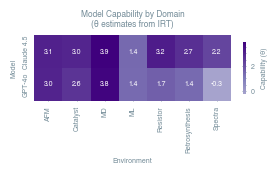

In [53]:
plot_capability_heatmap_(theta_df)